<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1197/2499498840.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_1197/2499498840.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_1197/2499498840.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CO(GT)'] = df['CO(GT)'].ffill().astype(float)
/tmp/ipykernel_1197/2499498840.py:22: F

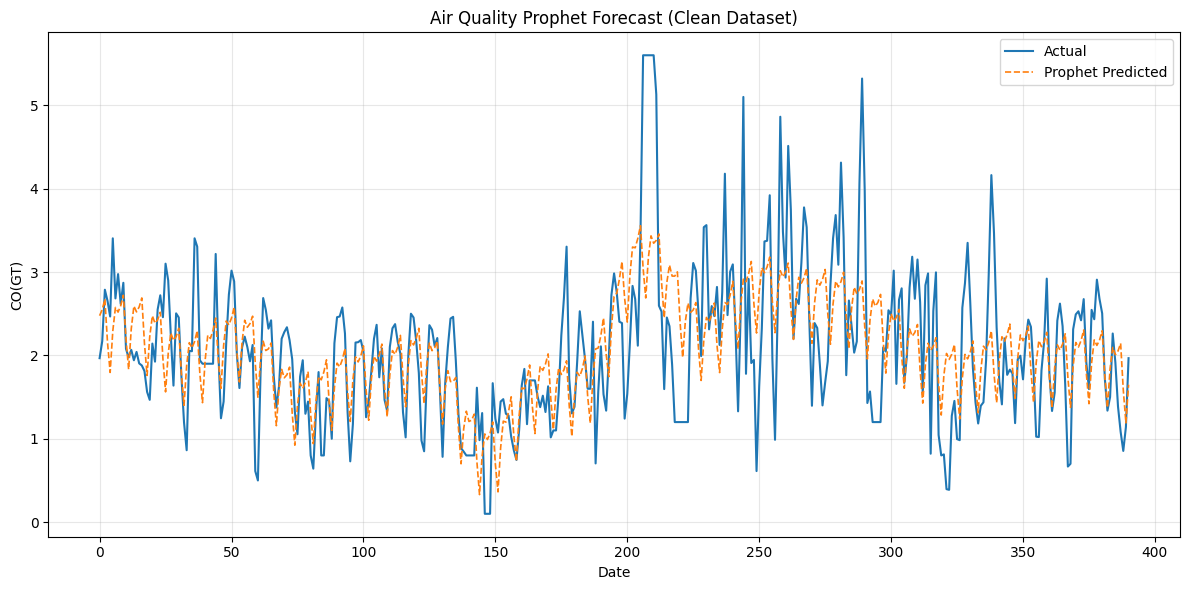

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Load and Preprocess the UCI Air Quality Dataset
url = "/content/AirQualityUCI.csv"
df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)

# Clean dataset structure
df.dropna(how='all', inplace=True)
df = df.iloc[:, :15]

# Convert and index datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df.dropna(subset=['Date_Time'], inplace=True)

# Replace missing values (-200) and forward fill
df.replace(-200, pd.NA, inplace=True)
df['CO(GT)'] = df['CO(GT)'].ffill().astype(float)

# Resample to daily frequency to mimic the data density in the target graph
daily_df = df.set_index('Date_Time').resample('D').mean().ffill().reset_index()

# Prophet requires a dataframe with columns explicitly named 'ds' and 'y'
prophet_df = daily_df[['Date_Time', 'CO(GT)']].rename(columns={'Date_Time': 'ds', 'CO(GT)': 'y'})

# 2. Fit the Prophet Model
# Prophet handles daily data well and automatically extracts weekly and yearly patterns
model = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(prophet_df)

# 3. Generate In-Sample Predictions
# Instead of forecasting the future, we pass the original dates back to get fitted historical values
forecast = model.predict(prophet_df)

# 4. Generate the Chart to Match Your Image Style
plt.figure(figsize=(12, 6), dpi=100)

# Plot actual historical data (using sequential indexing to match 0 to 1750+ timeline)
plt.plot(prophet_df['y'], label='Actual', color='#1f77b4', linestyle='-', linewidth=1.5)

# Plot prophet historical predictions as a dashed overlay
plt.plot(forecast['yhat'], label='Prophet Predicted', color='#ff7f0e', linestyle='--', linewidth=1.2)

# Customizing layout to match chart aesthetics
plt.title('Air Quality Prophet Forecast (Clean Dataset)', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')

# Subtle grid styling matching the reference image
plt.grid(True, linestyle='-', alpha=0.3)

# Display final graph
plt.tight_layout()
plt.show()
